In [ ]:
import math

In [ ]:
class Unit:
  def __init__(self, data, operation='', parents=()):
    self.data = data
    self.grad = 0
    self.operation = operation
    self._parents = parents
    self._label = ''
    self._backward = lambda : None

  def __add__(self, other):
    other = other if isinstance(other, Unit) else Unit(other)
    u = Unit(self.data+other.data, '+', (self,other))
    def backward():
      self.grad += 1 * u.grad
      other.grad += 1 * u.grad
    u._backward = backward
    return u

  def __mul__(self, other):
    other = other if isinstance(other, Unit) else Unit(other)
    u = Unit(self.data*other.data, '*',(self,other))
    def backward():
      self.grad += other.data * u.grad
      other.grad += self.data * u.grad
    u._backward = backward
    return u

  def cosx(self):
    cosTheta = math.cos(self.data)
    u = Unit(cosTheta, 'cos', (self,))
    def backward():
      self.grad += -1 * math.sin(self.data) * u.grad
    u._backward = backward
    return u

  def __pow__(self, other):
    u = Unit(self.data**other, f'**{other}', (self,))

    def backward():
        self.grad += (other * (self.data**(other - 1))) * u.grad

    u._backward = backward
    return u

  def __sub__(self, other): # self - other
    return self + (other * -1)

  def __neg__(self): # -self
    return self * -1

  def __radd__(self, other): # Handles 2 + Unit
    return self + other

  def __rmul__(self, other): # Handles 2 * Unit
    return self * other

  def backward(self):
    topo = []
    visited = set()
    def build_topo(v):
        if v not in visited:
            visited.add(v)
            for child in v._parents:
                build_topo(child)
            topo.append(v)
    build_topo(self)

    self.grad = 1.0

    for node in reversed(topo):
        node._backward()

x1 = Unit(5) ; x1.label = 'x1'
x2 = Unit(10) ; x2.label = 'x2'

w1 = Unit(2) ; w1.label = 'w1'
w2 = Unit(4) ; w2.label = 'w2'

x1w1 = x1*w1 ; x1w1.label = 'x1w1'
x2w2 = x2*w2 ; x2w2.label = 'x2w2'
b = Unit(3) ; b.label = 'b'

n = x1w1 + x2w2 + b ; n.label='n'
o = n.cosx() ; o.label = 'o'

f(x+h)-f(x) / h

* x1w1 = x1 * w1

* d(x1w1)/d(x1) = (((x1+h)*w1)-(x1*w1))/h
              = (x1w1+hw1-x1w1)/h
              = hw1/h = w1

* d(x1w1)/d(w1) = x1

* n = a + b

* dn/da = ((a+h)+b)-(a+b)/h = (a+h+b-a-b)/h
  dn/da = 1


In [ ]:
#topological order
topo = []
visited = set()

def trace(v):
    if v not in visited:
        visited.add(v)
        for child in v._parents:
            trace(child)
        topo.append(v)
trace(o)

o.grad = 1.0
for node in reversed(topo):
    node._backward()

In [ ]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            # Ensure parents is iterable (handling both single parent and tuples)
            parents = v._parents if isinstance(v._parents, (tuple, list, set)) else (v._parents,)
            for child in parents:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # Get label (handling the _label vs label attribute)
        label_val = getattr(n, 'label', getattr(n, '_label', ''))

        # Create a rectangular node for the Unit object (data and grad)
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (label_val, n.data, n.grad), shape='record')

        # If this node was created by an operation, create a circular op node
        if n.operation:
            dot.node(name = uid + n.operation, label = n.operation)
            dot.edge(uid + n.operation, uid)

    for n1, n2 in edges:
        # Connect the parent (n1) to the operation node that produced n2
        dot.edge(str(id(n1)), str(id(n2)) + n2.operation)

    return dot

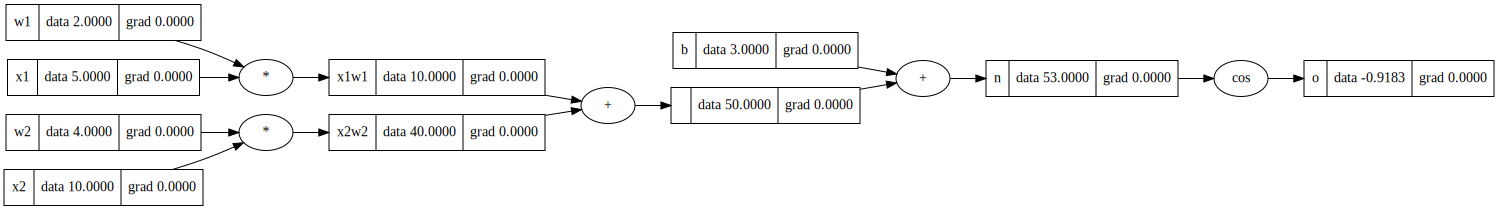

In [ ]:
draw_dot(o)

##Creating our own Neural n/w



In [ ]:
class Neuron:
    def __init__(self, nin):
        import random
        self.w = [Unit(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Unit(random.uniform(-1, 1))

    def __call__(self, x):
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        return act.cosx()

    def parameters(self):
        return self.w + [self.b]

In [ ]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0]

In [ ]:
def calculate_loss(model, xs, ys):
    ypred = [model(x) for x in xs]
    loss = sum([(yout - ygt)**2 for ygt, yout in zip(ys, ypred)])
    return loss

In [ ]:
model = Neuron(3)
for k in range(50):
    loss = calculate_loss(model, xs, ys)

    for p in model.parameters():
        p.grad = 0.0

    loss.backward()

    learning_rate = 0.001
    for p in model.parameters():
        p.data += -1 * learning_rate * p.grad

    print(f"Step {k} | Loss: {loss.data:.4f}")

Step 0 | Loss: 8.3028
Step 1 | Loss: 8.2171
Step 2 | Loss: 8.1319
Step 3 | Loss: 8.0474
Step 4 | Loss: 7.9636
Step 5 | Loss: 7.8806
Step 6 | Loss: 7.7985
Step 7 | Loss: 7.7172
Step 8 | Loss: 7.6367
Step 9 | Loss: 7.5571
Step 10 | Loss: 7.4782
Step 11 | Loss: 7.4000
Step 12 | Loss: 7.3223
Step 13 | Loss: 7.2450
Step 14 | Loss: 7.1680
Step 15 | Loss: 7.0912
Step 16 | Loss: 7.0145
Step 17 | Loss: 6.9377
Step 18 | Loss: 6.8607
Step 19 | Loss: 6.7834
Step 20 | Loss: 6.7057
Step 21 | Loss: 6.6275
Step 22 | Loss: 6.5487
Step 23 | Loss: 6.4693
Step 24 | Loss: 6.3892
Step 25 | Loss: 6.3084
Step 26 | Loss: 6.2269
Step 27 | Loss: 6.1448
Step 28 | Loss: 6.0621
Step 29 | Loss: 5.9788
Step 30 | Loss: 5.8951
Step 31 | Loss: 5.8110
Step 32 | Loss: 5.7267
Step 33 | Loss: 5.6423
Step 34 | Loss: 5.5580
Step 35 | Loss: 5.4738
Step 36 | Loss: 5.3901
Step 37 | Loss: 5.3069
Step 38 | Loss: 5.2244
Step 39 | Loss: 5.1428
Step 40 | Loss: 5.0621
Step 41 | Loss: 4.9827
Step 42 | Loss: 4.9046
Step 43 | Loss: 4.827